<a href="https://colab.research.google.com/github/Budde-Rohini/AI_Palmistry/blob/main/milestone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"budderohini","key":"6a70e6e8f6ab08f8294c12e41af6acda"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d axondata/palm-recognition-large-scale

Dataset URL: https://www.kaggle.com/datasets/axondata/palm-recognition-large-scale
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 855M/855M [00:09<00:00, 97.1MB/s]



In [ ]:
!unzip palm-recognition-large-scale.zip -d palm_dataset

Archive:  palm-recognition-large-scale.zip
  inflating: palm_dataset/contactless-palmprint-sample/metadata_sample.json  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/left_hand_back_cam/left_hand_back_cam_1.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/left_hand_back_cam/left_hand_back_cam_2.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/left_hand_back_cam/left_hand_back_cam_3.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/left_hand_front_cam/left_hand_front_cam_1.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/left_hand_front_cam/left_hand_front_cam_2.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/left_hand_front_cam/left_hand_front_cam_3.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/right_hand_back_cam/right_hand_back_cam_1.jpg  
  inflating: palm_dataset/contactless-palmprint-sample/user_1/right_hand_back_cam/right_hand_back_cam_2.jpg  
  inf

In [ ]:
import os

for root, dirs, files in os.walk("palm_dataset"):
    print(root, len(files))

palm_dataset 1
palm_dataset/contactless-palmprint-sample 1
palm_dataset/contactless-palmprint-sample/user_3 0
palm_dataset/contactless-palmprint-sample/user_3/right_hand_front_cam 3
palm_dataset/contactless-palmprint-sample/user_3/right_hand_back_cam 3
palm_dataset/contactless-palmprint-sample/user_3/left_hand_front_cam 3
palm_dataset/contactless-palmprint-sample/user_3/left_hand_back_cam 3
palm_dataset/contactless-palmprint-sample/user_9 0
palm_dataset/contactless-palmprint-sample/user_9/right_hand_front_cam 3
palm_dataset/contactless-palmprint-sample/user_9/right_hand_back_cam 3
palm_dataset/contactless-palmprint-sample/user_9/left_hand_front_cam 3
palm_dataset/contactless-palmprint-sample/user_9/left_hand_back_cam 3
palm_dataset/contactless-palmprint-sample/user_29 0
palm_dataset/contactless-palmprint-sample/user_29/right_hand_front_cam 3
palm_dataset/contactless-palmprint-sample/user_29/right_hand_back_cam 3
palm_dataset/contactless-palmprint-sample/user_29/left_hand_front_cam 3
pa

In [ ]:
import glob

images = glob.glob("palm_dataset/**/*.jpg", recursive=True)

print("Total Images:", len(images))

Total Images: 360


In [ ]:
images = glob.glob("palm_dataset/**/*.png", recursive=True)

print(len(images))

0


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    print(root, len(files))

/content 2
/content/.config 8
/content/.config/configurations 1
/content/.config/logs 0
/content/.config/logs/2026.06.04 6
/content/palm_dataset 1
/content/palm_dataset/contactless-palmprint-sample 1
/content/palm_dataset/contactless-palmprint-sample/user_3 0
/content/palm_dataset/contactless-palmprint-sample/user_3/right_hand_front_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_3/right_hand_back_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_3/left_hand_front_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_3/left_hand_back_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_9 0
/content/palm_dataset/contactless-palmprint-sample/user_9/right_hand_front_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_9/right_hand_back_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_9/left_hand_front_cam 3
/content/palm_dataset/contactless-palmprint-sample/user_9/left_hand_back_cam 3
/content/palm_dataset/contactless-palmpr

In [ ]:
import glob

images = []

images.extend(glob.glob("/content/**/*.jpg", recursive=True))
images.extend(glob.glob("/content/**/*.jpeg", recursive=True))
images.extend(glob.glob("/content/**/*.png", recursive=True))

print("Total images:", len(images))

Total images: 360


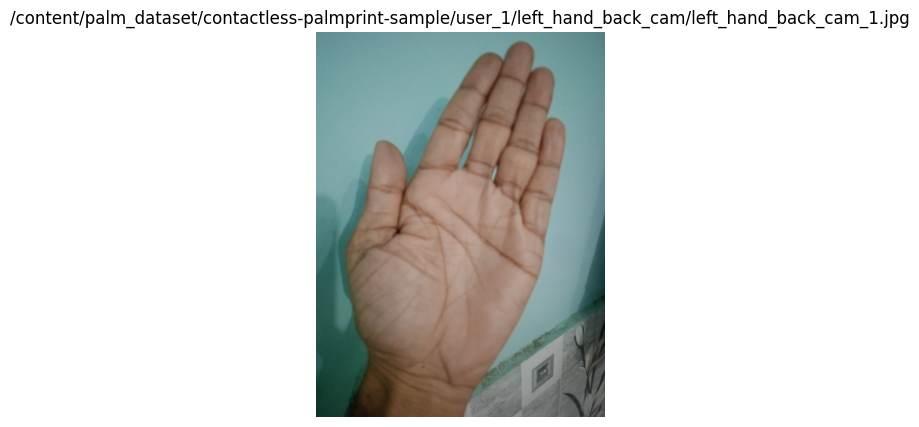

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

if len(images) == 0:
    print("No images found. Download the dataset first.")
else:
    img_path = random.choice(images)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(img_path)
    plt.axis("off")
    plt.show()

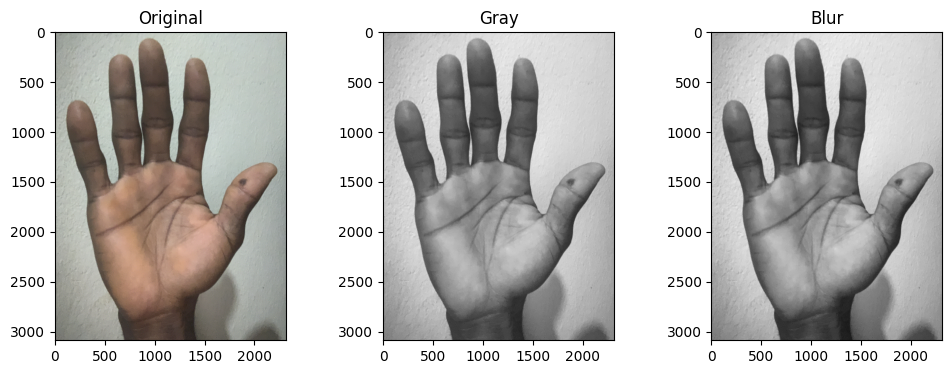

In [ ]:
import cv2

image_path=images[0]

img=cv2.imread(image_path)

rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

blur=cv2.GaussianBlur(gray,(5,5),0)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(rgb)
plt.title("Original")

plt.subplot(132)
plt.imshow(gray,cmap="gray")
plt.title("Gray")

plt.subplot(133)
plt.imshow(blur,cmap="gray")
plt.title("Blur")

plt.show()

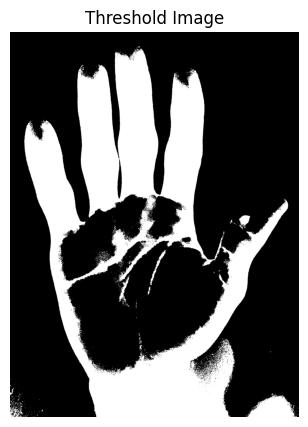

In [ ]:
# Step 6.1 - Thresholding

_, thresh = cv2.threshold(
    blur,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(5,5))
plt.imshow(thresh, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

In [ ]:
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

Number of contours: 2015


In [ ]:
largest = max(contours, key=cv2.contourArea)

print("Largest contour found.")

Largest contour found.


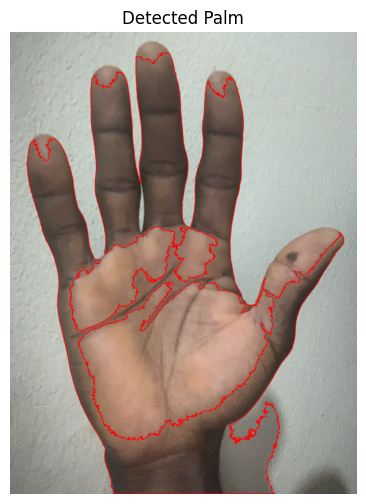

In [ ]:
output = rgb.copy()

cv2.drawContours(
    output,
    [largest],
    -1,
    (255,0,0),
    3
)

plt.figure(figsize=(6,6))
plt.imshow(output)
plt.title("Detected Palm")
plt.axis("off")
plt.show()

In [ ]:
area = cv2.contourArea(largest)

print("Palm Area:", area)

Palm Area: 2081248.5


In [ ]:
perimeter = cv2.arcLength(
    largest,
    True
)

print("Palm Perimeter:", perimeter)

Palm Perimeter: 42610.35492348671


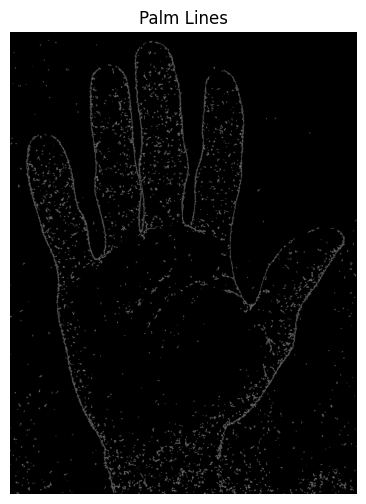

In [ ]:
edges = cv2.Canny(
    gray,
    50,
    150
)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap="gray")
plt.title("Palm Lines")
plt.axis("off")
plt.show()

In [ ]:
line_count = cv2.countNonZero(edges)

print("Palm Line Count:", line_count)

Palm Line Count: 111695


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Palm Area":[area],
    "Palm Perimeter":[perimeter],
    "Palm Line Count":[line_count]
})

df

,Palm Area,Palm Perimeter,Palm Line Count
0,2081248.5,42610.354923,111695


In [ ]:
df.to_csv(
    "palm_features.csv",
    index=False
)

print("Palm features saved successfully.")

Palm features saved successfully.


In [ ]:
print("="*40)
print("PALM FEATURE SUMMARY")
print("="*40)

print(f"Palm Area       : {area:.2f}")
print(f"Palm Perimeter  : {perimeter:.2f}")
print(f"Palm Line Count : {line_count}")

PALM FEATURE SUMMARY
Palm Area       : 2081248.50
Palm Perimeter  : 42610.35
Palm Line Count : 111695


In [ ]:
prompt = f"""
Disclaimer:
This is an AI-generated entertainment reading.

Palm Features

Palm Area: {area:.2f}

Palm Perimeter: {perimeter:.2f}

Palm Line Count: {line_count}

Generate a detailed report with the following headings:

1. Personality Analysis

2. Career Guidance

3. Strengths

4. Challenges

5. Motivational Advice
"""

print(prompt)


Disclaimer:
This is an AI-generated entertainment reading.

Palm Features

Palm Area: 2081248.50

Palm Perimeter: 42610.35

Palm Line Count: 111695

Generate a detailed report with the following headings:

1. Personality Analysis

2. Career Guidance

3. Strengths

4. Challenges

5. Motivational Advice



In [ ]:
reading = f"""
# 🔮 AI Palm Reading

Disclaimer:
This is an AI-generated entertainment reading.

## Personality Analysis
You appear analytical, focused, and determined. Your palm features suggest a practical mindset with good observation skills.

## Career Guidance
Suitable fields include Software Development, Artificial Intelligence, Data Science, Cyber Security, Electronics, and Research.

## Strengths
• Logical Thinking
• Fast Learning
• Determination
• Strong Problem Solving

## Challenges
• Overthinking
• Stress during deadlines
• Difficulty balancing work and personal life

## Motivational Advice
Believe in continuous learning. Your greatest strength is your ability to improve through persistence.
"""

print(reading)


# 🔮 AI Palm Reading

Disclaimer:
This is an AI-generated entertainment reading.

## Personality Analysis
You appear analytical, focused, and determined. Your palm features suggest a practical mindset with good observation skills.

## Career Guidance
Suitable fields include Software Development, Artificial Intelligence, Data Science, Cyber Security, Electronics, and Research.

## Strengths
• Logical Thinking
• Fast Learning
• Determination
• Strong Problem Solving

## Challenges
• Overthinking
• Stress during deadlines
• Difficulty balancing work and personal life

## Motivational Advice
Believe in continuous learning. Your greatest strength is your ability to improve through persistence.



In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
from PIL import Image

st.set_page_config(page_title="AI Palm Reader", layout="centered")

st.title("🔮 AI Palm Reading System")

uploaded_file = st.file_uploader(
    "Upload Palm Image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:

    image = Image.open(uploaded_file)

    img = np.array(image)

    rgb = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(rgb, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(
        blur,
        120,
        255,
        cv2.THRESH_BINARY_INV
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    largest = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(largest)

    perimeter = cv2.arcLength(
        largest,
        True
    )

    edges = cv2.Canny(
        gray,
        50,
        150
    )

    line_count = cv2.countNonZero(edges)

    st.image(image, caption="Uploaded Palm", use_container_width=True)

    st.subheader("Extracted Features")

    st.write("Palm Area :", area)
    st.write("Palm Perimeter :", perimeter)
    st.write("Palm Line Count :", line_count)

    if st.button("Generate Reading"):

        st.markdown(f"""
# 🔮 AI Palm Reading

### Personality Analysis
You appear analytical, focused and determined.

### Career Guidance
Artificial Intelligence

Electronics

Software Development

Cyber Security

Research

### Strengths
✔ Logical Thinking

✔ Creativity

✔ Determination

✔ Fast Learning

### Challenges
• Overthinking

• Stress

• Lack of patience

### Motivational Advice
Never stop learning. Your consistency will become your greatest strength.
""")

Writing app.py


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.2 MB/s eta 0:00:00


In [ ]:
!streamlit --version

Streamlit, version 1.61.0


In [ ]:
!ls

sample_data


In [ ]:
%%writefile app.py

import streamlit as st

st.title("AI Palm Reading")
st.write("Hello from Streamlit!")

Writing app.py


In [ ]:
!streamlit run app.py &



2026-08-05 05:14:57.109 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.46.28.122:8501

